# Smart City Traffic Management and Route Optimization System

**Project notebook** · ENCA351 Design and Analysis of Algorithms Lab · BCA (AI&DS), Semester V

**Submitted by:** Shreyansh Vaibhaw (2401201094)

This notebook walks through every module of the project on the sample city, and then runs the
comparative analysis (Task 8) on random cities with 10, 25, 50 and 100 intersections.

All algorithms are implemented by hand in the project modules. NetworkX is only used to draw the maps.

| Module | File | Algorithms |
|---|---|---|
| Road Network Modeling | `road_network.py` | adjacency list, adjacency matrix |
| Route Planning | `route_planner.py` | Dijkstra |
| Traffic Analysis | `traffic_analysis.py` | Bellman-Ford, congestion simulation |
| Network Connectivity | `connectivity_module.py` | Breadth First Search, Depth First Search |
| Infrastructure Planning | `mst_planner.py` | Prim, Kruskal |
| Comparative Analysis | `experiments.py` | timing and memory measurements |

In [1]:
import os

import pandas as pd
import matplotlib.pyplot as plt

from road_network import RoadNetwork
from route_planner import dijkstra, path_cost
from traffic_analysis import bellman_ford, apply_congestion, congest_route, compare_routes
from connectivity_module import bfs, dfs, tree_roads, connected_regions
from mst_planner import prim, kruskal, same_roads
from experiments import run_experiments, comparison_table, timing_chart
from visualizer import (draw_network, positions_for, format_path, format_cost,
                        steps_table, distance_table, edges_table)

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)
os.makedirs("results/figures", exist_ok=True)


def save(figure, name):
    # Show the figure here and also save it, so the report can reuse it.
    figure.savefig(f"results/figures/{name}.png", dpi=110, bbox_inches="tight")
    plt.show()

## 1. Road Network Modeling

The city is a weighted, undirected graph. Every intersection is a vertex, every road is an edge and the
travel cost (here: minutes) is the edge weight. The sample city has 10 intersections and 15 roads.

In [2]:
city = RoadNetwork.sample_city()
print("Intersections:", city.number_of_intersections())
print("Roads:", city.number_of_roads())
print()
print("Adjacency list")
print("\n".join(city.adjacency_list_text()))

Intersections: 10
Roads: 15

Adjacency list
Central Square -> City Hospital (5), Old Market (2), Railway Station (4)
Railway Station -> Bus Terminal (3), Central Square (4), University (7)
Old Market -> Bus Terminal (6), Central Square (2), Riverside (3)
City Hospital -> Central Square (5), Stadium (7), University (4)
Bus Terminal -> Old Market (6), Railway Station (3), Tech Park (9)
University -> City Hospital (4), Railway Station (7), Stadium (3), Tech Park (5)
Riverside -> Old Market (3), Stadium (7)
Stadium -> Airport Road (9), City Hospital (7), Riverside (7), University (3)
Tech Park -> Airport Road (6), Bus Terminal (9), University (5)
Airport Road -> Stadium (9), Tech Park (6)


In [3]:
print("Adjacency matrix (0 = no direct road)")
city.adjacency_matrix()

Adjacency matrix (0 = no direct road)


,Central Square,Railway Station,Old Market,City Hospital,Bus Terminal,University,Riverside,Stadium,Tech Park,Airport Road
Central Square,0.0,4.0,2.0,5.0,0.0,0.0,0.0,0.0,0.0,0.0
Railway Station,4.0,0.0,0.0,0.0,3.0,7.0,0.0,0.0,0.0,0.0
Old Market,2.0,0.0,0.0,0.0,6.0,0.0,3.0,0.0,0.0,0.0
City Hospital,5.0,0.0,0.0,0.0,0.0,4.0,0.0,7.0,0.0,0.0
Bus Terminal,0.0,3.0,6.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0
University,0.0,7.0,0.0,4.0,0.0,0.0,0.0,3.0,5.0,0.0
Riverside,0.0,0.0,3.0,0.0,0.0,0.0,0.0,7.0,0.0,0.0
Stadium,0.0,0.0,0.0,7.0,0.0,3.0,7.0,0.0,0.0,9.0
Tech Park,0.0,0.0,0.0,0.0,9.0,5.0,0.0,0.0,0.0,6.0
Airport Road,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.0,6.0,0.0


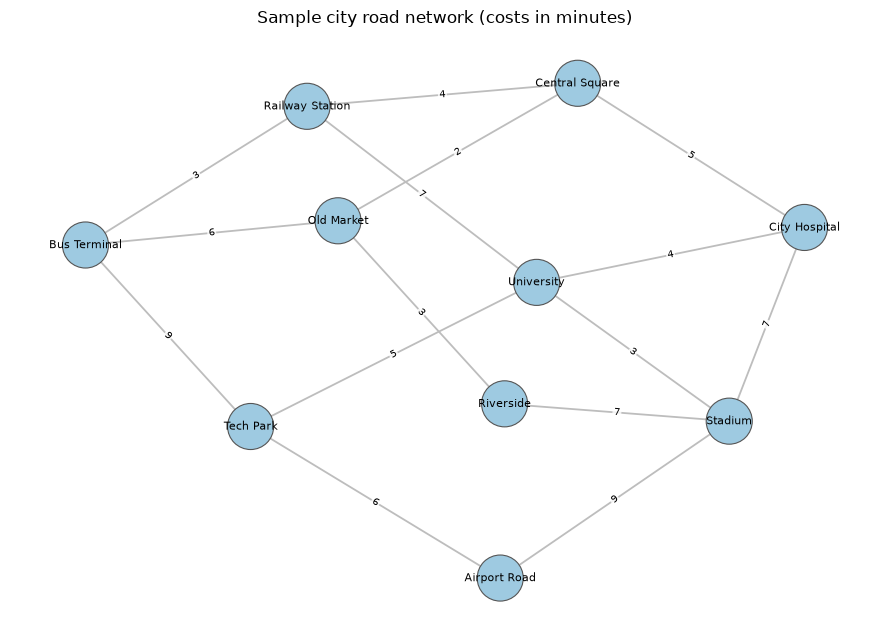

In [4]:
positions = positions_for(city)
save(draw_network(city, positions, title="Sample city road network (costs in minutes)"), "01_city_map")

## 2. Route Planning with Dijkstra's algorithm

A commuter wants to travel from **Central Square** to **Airport Road** in the least time.
Dijkstra's algorithm repeatedly settles the closest unvisited intersection and relaxes its roads.
Every distance update is recorded so that the working can be shown.

In [5]:
source, destination = "Central Square", "Airport Road"
route = dijkstra(city, source, destination)

print("Shortest route:", format_path(route["path"]))
print("Total travel cost:", format_cost(route["cost"], "minutes"))
print("Check by adding up the road costs:", path_cost(city, route["path"]))
print("Order in which intersections were finalised:")
print("  " + " -> ".join(route["visit_order"]))

Shortest route: Central Square → City Hospital → University → Tech Park → Airport Road
Total travel cost: 20 minutes
Check by adding up the road costs: 20.0
Order in which intersections were finalised:
  Central Square -> Old Market -> Railway Station -> City Hospital -> Riverside -> Bus Terminal -> University -> Stadium -> Tech Park -> Airport Road


In [6]:
print("Every intermediate distance update:")
steps_table(route["steps"])

Every intermediate distance update:


,Step,Visiting,Road to,Road cost,Old distance,New distance
0,1,Central Square,Railway Station,4,∞,4
1,2,Central Square,Old Market,2,∞,2
2,3,Central Square,City Hospital,5,∞,5
3,4,Old Market,Bus Terminal,6,∞,8
4,5,Old Market,Riverside,3,∞,5
5,6,Railway Station,Bus Terminal,3,8,7
6,7,Railway Station,University,7,∞,11
7,8,City Hospital,University,4,11,9
8,9,City Hospital,Stadium,7,∞,12
9,10,Bus Terminal,Tech Park,9,∞,16


In [7]:
print("Distance table after each visited intersection:")
distance_table(route["table"], "Visited")

Distance table after each visited intersection:


,Central Square,Railway Station,Old Market,City Hospital,Bus Terminal,University,Riverside,Stadium,Tech Park,Airport Road
Visited,,,,,,,,,,
Central Square,0,4,2,5,∞,∞,∞,∞,∞,∞
Old Market,0,4,2,5,8,∞,5,∞,∞,∞
Railway Station,0,4,2,5,7,11,5,∞,∞,∞
City Hospital,0,4,2,5,7,9,5,12,∞,∞
Riverside,0,4,2,5,7,9,5,12,∞,∞
Bus Terminal,0,4,2,5,7,9,5,12,16,∞
University,0,4,2,5,7,9,5,12,14,∞
Stadium,0,4,2,5,7,9,5,12,14,21
Tech Park,0,4,2,5,7,9,5,12,14,20


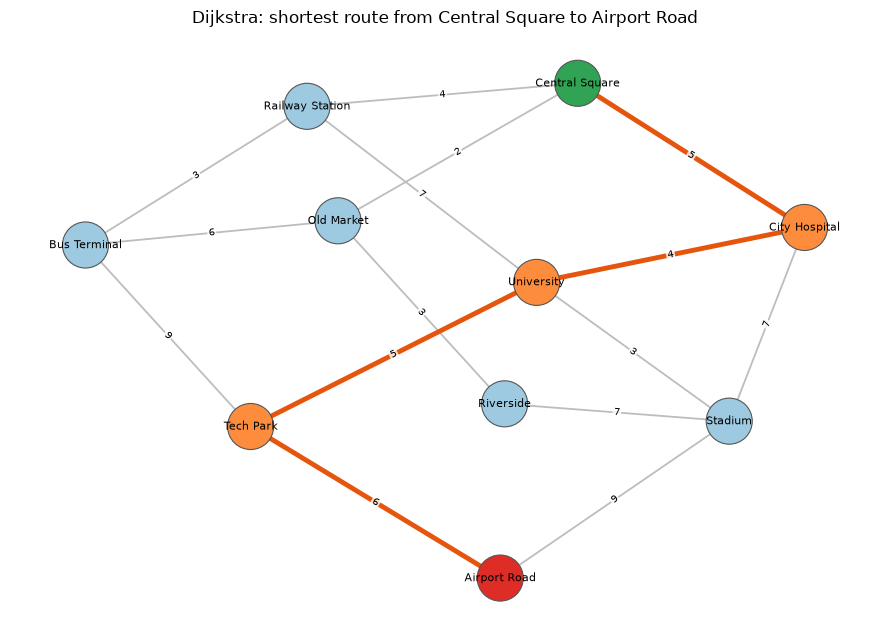

In [8]:
save(draw_network(city, positions, highlight_path=route["path"], start=source, end=destination,
                  title=f"Dijkstra: shortest route from {source} to {destination}"), "02_dijkstra_route")

## 3. Traffic Analysis with the Bellman-Ford algorithm

Bellman-Ford relaxes **every** road in each pass and repeats until nothing changes. On the original city it
must give the same answer as Dijkstra. City administrators then change road costs to simulate congestion
and compare the route before and after.

In [9]:
before = bellman_ford(city, source, destination)
print("Bellman-Ford route:", format_path(before["path"]), "| cost:", format_cost(before["cost"], "minutes"))
print("Passes run:", before["passes_needed"], "of at most", city.number_of_intersections() - 1,
      "(the last pass only confirms that nothing changes)")
print("Same answer as Dijkstra:", before["path"] == route["path"] and before["cost"] == route["cost"])
print()
print("Distance table after each pass:")
distance_table(before["passes"], "Pass")

Bellman-Ford route: Central Square → City Hospital → University → Tech Park → Airport Road | cost: 20 minutes
Passes run: 2 of at most 9 (the last pass only confirms that nothing changes)
Same answer as Dijkstra: True

Distance table after each pass:


,Central Square,Railway Station,Old Market,City Hospital,Bus Terminal,University,Riverside,Stadium,Tech Park,Airport Road
Pass,,,,,,,,,,
1,0,4,2,5,7,9,5,12,14,20
2,0,4,2,5,7,9,5,12,14,20


In [10]:
# Scenario 1: peak-hour traffic triples the travel time of every road on the current shortest route.
changes = congest_route(city, route["path"], factor=3)
congested = apply_congestion(city, changes)
comparison = compare_routes(city, congested, source, destination)

print("Congested roads:")
for change in changes:
    old = city.get_cost(change["from"], change["to"])
    print(f"  {change['from']} - {change['to']}: {old:g} -> {change['new_cost']:g} minutes")
print()
print("Original route:", format_path(comparison["original_path"]), "| cost", format_cost(comparison["original_cost"]))
print("Updated route: ", format_path(comparison["updated_path"]), "| cost", format_cost(comparison["updated_cost"]))
print(f"Extra travel cost: {comparison['extra_cost']:g} minutes ({comparison['percent_increase']:.0f}% more)")
print("Route changed:", comparison["route_changed"])

Congested roads:
  Central Square - City Hospital: 5 -> 15 minutes
  City Hospital - University: 4 -> 12 minutes
  University - Tech Park: 5 -> 15 minutes
  Tech Park - Airport Road: 6 -> 18 minutes

Original route: Central Square → City Hospital → University → Tech Park → Airport Road | cost 20
Updated route:  Central Square → Old Market → Riverside → Stadium → Airport Road | cost 21
Extra travel cost: 1 minutes (5% more)
Route changed: True


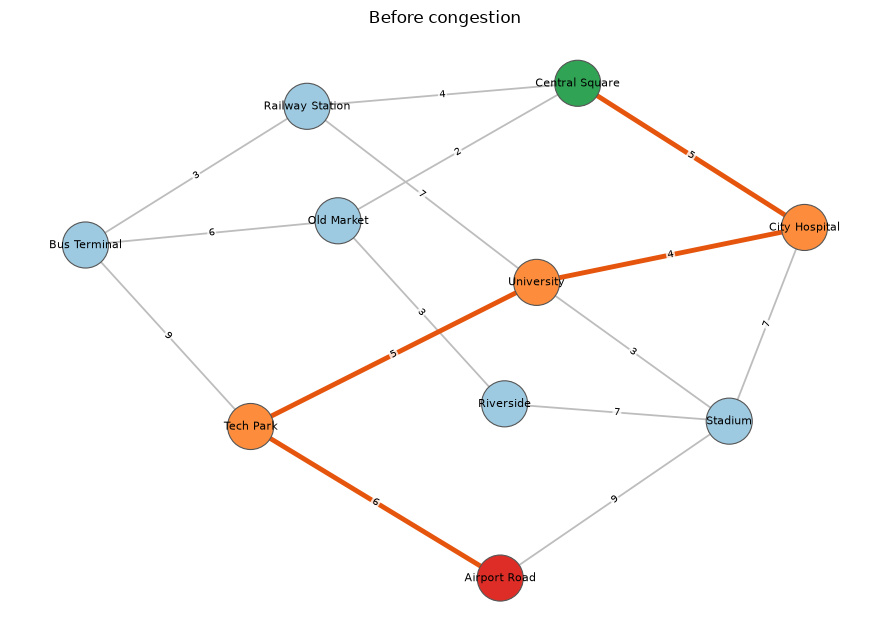

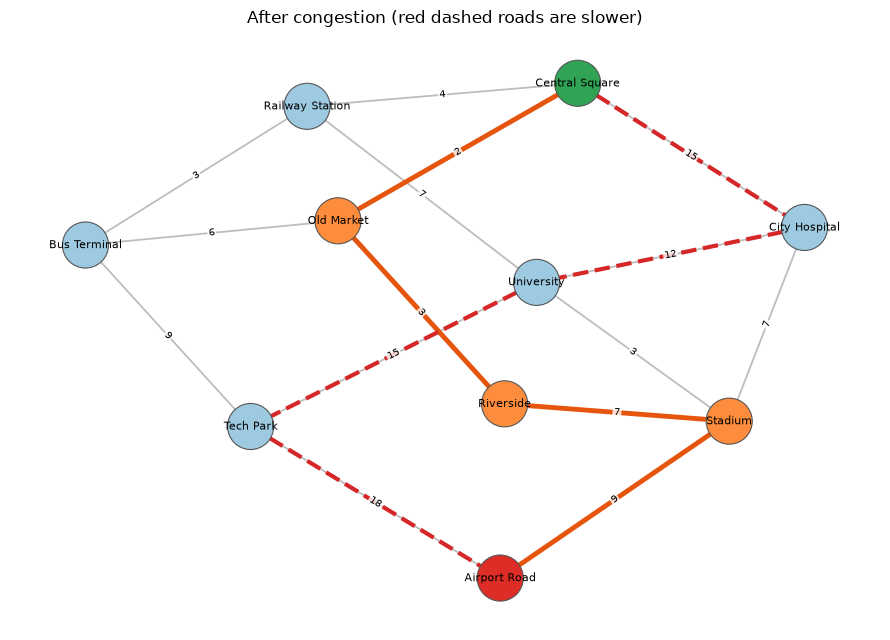

In [11]:
changed_roads = [(change["from"], change["to"]) for change in changes]
save(draw_network(city, positions, highlight_path=comparison["original_path"], start=source, end=destination,
                  title="Before congestion"), "03_before_congestion")
save(draw_network(congested, positions, highlight_path=comparison["updated_path"], changed_roads=changed_roads,
                  start=source, end=destination, title="After congestion (red dashed roads are slower)"),
     "03_after_congestion")

In [12]:
print("Bellman-Ford on the congested city, distance table after each pass:")
distance_table(comparison["after"]["passes"], "Pass")

Bellman-Ford on the congested city, distance table after each pass:


,Central Square,Railway Station,Old Market,City Hospital,Bus Terminal,University,Riverside,Stadium,Tech Park,Airport Road
Pass,,,,,,,,,,
1,0,4,2,15,7,11,5,12,16,21
2,0,4,2,15,7,11,5,12,16,21


In [13]:
# Scenario 2: an accident closes the road between University and Tech Park completely.
closure = apply_congestion(city, [{"from": "University", "to": "Tech Park", "new_cost": None}])
closed_comparison = compare_routes(city, closure, source, destination)
print("Route after the closure:", format_path(closed_comparison["updated_path"]),
      "| cost", format_cost(closed_comparison["updated_cost"], "minutes"))
print("Extra travel cost:", format_cost(closed_comparison["extra_cost"], "minutes"))

Route after the closure: Central Square → City Hospital → Stadium → Airport Road | cost 21 minutes
Extra travel cost: 1 minutes


## 4. Network Connectivity with BFS and DFS

Both traversals start at Central Square and visit every intersection that can be reached by road.
BFS uses a queue and spreads level by level; DFS uses recursion (a stack) and follows one road as far
as it goes before backtracking.

In [14]:
start = "Central Square"
bfs_result = bfs(city, start)
dfs_result = dfs(city, start)
print("BFS order:", format_path(bfs_result["order"]))
print("DFS order:", format_path(dfs_result["order"]))
print("Reachable intersections:", len(bfs_result["reachable"]), "| unreachable:", bfs_result["unreachable"] or "none")

BFS order: Central Square → Railway Station → Old Market → City Hospital → Bus Terminal → University → Riverside → Stadium → Tech Park → Airport Road
DFS order: Central Square → Railway Station → Bus Terminal → Old Market → Riverside → Stadium → City Hospital → University → Tech Park → Airport Road
Reachable intersections: 10 | unreachable: none


In [15]:
print("BFS step by step (queue contents after each step):")
steps_table(bfs_result["steps"])

BFS step by step (queue contents after each step):


,Step,Visiting,Level,Newly discovered,Queue after this step
0,1,Central Square,0,"Railway Station, Old Market, City Hospital","Railway Station, Old Market, City Hospital"
1,2,Railway Station,1,"Bus Terminal, University","Old Market, City Hospital, Bus Terminal, Unive..."
2,3,Old Market,1,Riverside,"City Hospital, Bus Terminal, University, River..."
3,4,City Hospital,1,Stadium,"Bus Terminal, University, Riverside, Stadium"
4,5,Bus Terminal,2,Tech Park,"University, Riverside, Stadium, Tech Park"
5,6,University,2,-,"Riverside, Stadium, Tech Park"
6,7,Riverside,2,-,"Stadium, Tech Park"
7,8,Stadium,2,Airport Road,"Tech Park, Airport Road"
8,9,Tech Park,3,-,Airport Road
9,10,Airport Road,3,-,(empty)


In [16]:
print("DFS step by step (the current route shows the recursion stack):")
steps_table(dfs_result["steps"])

DFS step by step (the current route shows the recursion stack):


,Step,Visiting,Depth,Route from start
0,1,Central Square,0,Central Square
1,2,Railway Station,1,Central Square -> Railway Station
2,3,Bus Terminal,2,Central Square -> Railway Station -> Bus Terminal
3,4,Old Market,3,Central Square -> Railway Station -> Bus Termi...
4,5,Riverside,4,Central Square -> Railway Station -> Bus Termi...
5,6,Stadium,5,Central Square -> Railway Station -> Bus Termi...
6,7,City Hospital,6,Central Square -> Railway Station -> Bus Termi...
7,8,University,7,Central Square -> Railway Station -> Bus Termi...
8,9,Tech Park,8,Central Square -> Railway Station -> Bus Termi...
9,10,Airport Road,9,Central Square -> Railway Station -> Bus Termi...


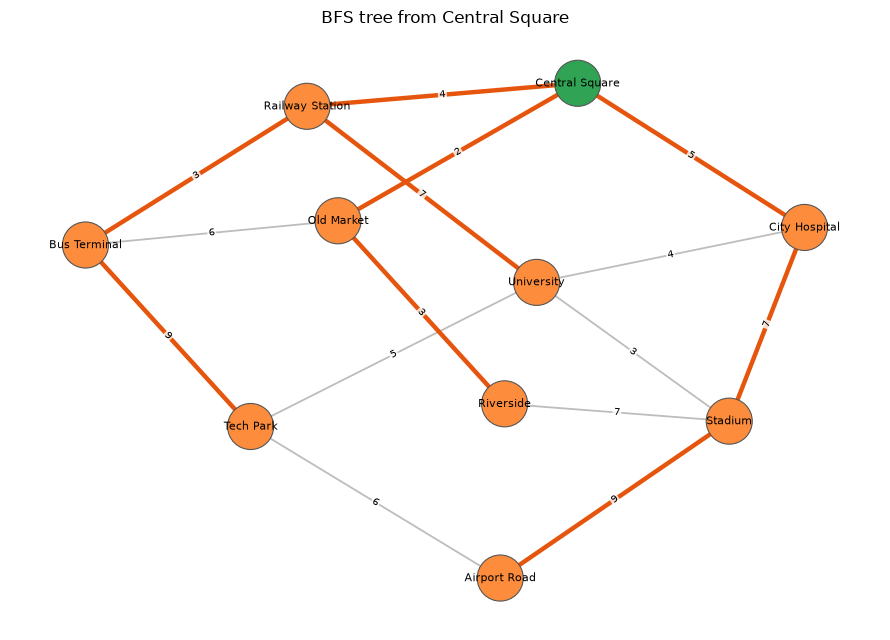

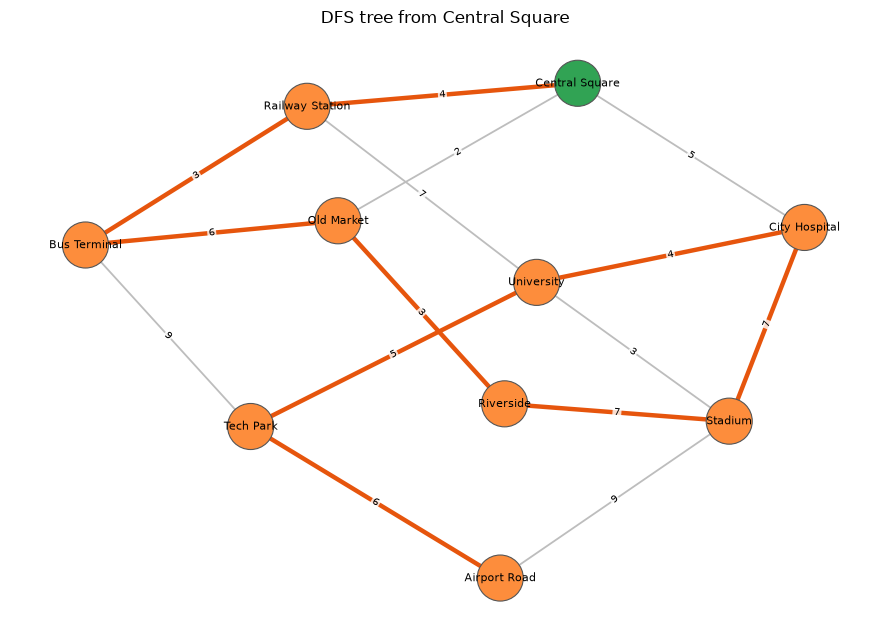

In [17]:
# tree_roads() gives the roads along which each intersection was first reached
save(draw_network(city, positions, highlight_edges=tree_roads(bfs_result), highlight_nodes=bfs_result["order"],
                  start=start, title="BFS tree from Central Square"), "04_bfs_tree")
save(draw_network(city, positions, highlight_edges=tree_roads(dfs_result), highlight_nodes=dfs_result["order"],
                  start=start, title="DFS tree from Central Square"), "04_dfs_tree")

In [18]:
# What if both roads into Airport Road are closed? The airport becomes a separate region.
cut_off = apply_congestion(city, [{"from": "Tech Park", "to": "Airport Road", "new_cost": None},
                                  {"from": "Stadium", "to": "Airport Road", "new_cost": None}])
result = bfs(cut_off, start)
print("Reachable from Central Square:", len(result["reachable"]), "| unreachable:", result["unreachable"])
for number, region in enumerate(connected_regions(cut_off), start=1):
    print(f"Region {number}: {', '.join(region)}")

Reachable from Central Square: 9 | unreachable: ['Airport Road']
Region 1: Central Square, Railway Station, Old Market, City Hospital, Bus Terminal, University, Riverside, Stadium, Tech Park
Region 2: Airport Road


## 5. Infrastructure Planning with Prim's and Kruskal's algorithms

The city wants to connect all intersections with the cheapest set of roads: a minimum spanning tree.
Both algorithms must produce the same total cost; they may choose different roads when costs tie.

In [19]:
prim_result = prim(city, start="Central Square")
kruskal_result = kruskal(city)
print("Prim total cost:   ", format_cost(prim_result["total_cost"]))
print("Kruskal total cost:", format_cost(kruskal_result["total_cost"]))
print("Roads kept:", len(kruskal_result["mst_edges"]), "of", city.number_of_roads())
print("Cost of building every road:", format_cost(city.total_cost()),
      "| saved by the MST:", format_cost(city.total_cost() - kruskal_result["total_cost"]))
print("Same roads chosen by both algorithms:", same_roads(prim_result["mst_edges"], kruskal_result["mst_edges"]))
print()
print("Roads selected by Kruskal:")
edges_table(kruskal_result["mst_edges"])

Prim total cost:    35
Kruskal total cost: 35
Roads kept: 9 of 15
Cost of building every road: 80 | saved by the MST: 45
Same roads chosen by both algorithms: True

Roads selected by Kruskal:


,From,To,Cost
0,Central Square,Old Market,2.0
1,Railway Station,Bus Terminal,3.0
2,Old Market,Riverside,3.0
3,University,Stadium,3.0
4,Central Square,Railway Station,4.0
5,City Hospital,University,4.0
6,Central Square,City Hospital,5.0
7,University,Tech Park,5.0
8,Tech Park,Airport Road,6.0


In [20]:
print("Prim's algorithm step by step:")
steps_table(prim_result["steps"])

Prim's algorithm step by step:


,Step,Road,Cost,Decision
0,1,Central Square - Old Market,2,Added to the tree
1,2,Old Market - Riverside,3,Added to the tree
2,3,Central Square - Railway Station,4,Added to the tree
3,4,Railway Station - Bus Terminal,3,Added to the tree
4,5,Central Square - City Hospital,5,Added to the tree
5,6,City Hospital - University,4,Added to the tree
6,7,University - Stadium,3,Added to the tree
7,8,University - Tech Park,5,Added to the tree
8,9,Old Market - Bus Terminal,6,Skipped (both ends already connected)
9,10,Tech Park - Airport Road,6,Added to the tree


In [21]:
print("Kruskal's algorithm step by step:")
steps_table(kruskal_result["steps"])

Kruskal's algorithm step by step:


,Step,Road,Cost,Decision
0,1,Central Square - Old Market,2,Added to the tree
1,2,Railway Station - Bus Terminal,3,Added to the tree
2,3,Old Market - Riverside,3,Added to the tree
3,4,University - Stadium,3,Added to the tree
4,5,Central Square - Railway Station,4,Added to the tree
5,6,City Hospital - University,4,Added to the tree
6,7,Central Square - City Hospital,5,Added to the tree
7,8,University - Tech Park,5,Added to the tree
8,9,Old Market - Bus Terminal,6,Rejected (would create a cycle)
9,10,Tech Park - Airport Road,6,Added to the tree


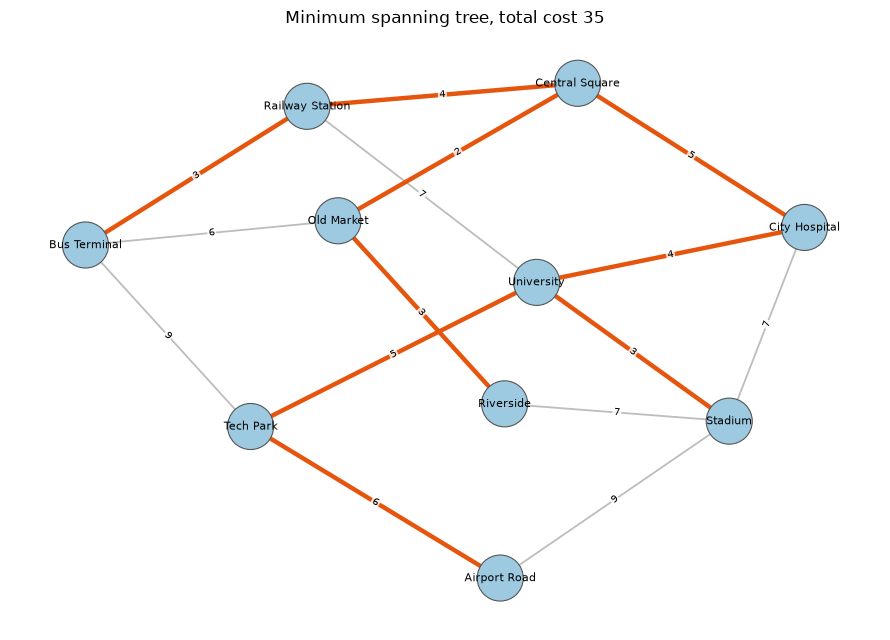

In [22]:
save(draw_network(city, positions, highlight_edges=kruskal_result["mst_edges"],
                  title=f"Minimum spanning tree, total cost {kruskal_result['total_cost']:g}"), "05_mst")

## 6. Comparative Analysis (Task 8)

Random but connected cities with **10, 25, 50 and 100 intersections** are generated (about two roads per
intersection, costs between 1 and 20). Every algorithm runs on every city. Execution time is the median
of 30 runs with the step-by-step recording switched off, so only the algorithm itself is timed. Peak
memory is measured with `tracemalloc`. The route is always from the first to the last intersection.

In [23]:
sizes = (10, 25, 50, 100)
results = run_experiments(sizes, repeats=30)
results.to_csv("results/experiment_results.csv", index=False)
results

,Intersections,Roads,Category,Algorithm,Execution time (ms),Peak memory (KB),Route length (roads),Route cost,Distance updates,Passes,Reachable intersections,MST roads,MST cost
0,10,20,Shortest path,Dijkstra,0.0120,1.5,2.0,27.0,12.0,NaN,NaN,NaN,NaN
1,10,20,Shortest path,Bellman-Ford,0.0272,3.4,2.0,27.0,13.0,2.0,NaN,NaN,NaN
2,10,20,Traversal,BFS,0.0068,2.2,NaN,NaN,NaN,NaN,10.0,NaN,NaN
3,10,20,Traversal,DFS,0.0083,2.7,NaN,NaN,NaN,NaN,10.0,NaN,NaN
4,10,20,Minimum spanning tree,Prim,0.0147,1.4,NaN,NaN,NaN,NaN,NaN,9.0,43.0
5,10,20,Minimum spanning tree,Kruskal,0.0236,3.8,NaN,NaN,NaN,NaN,NaN,9.0,43.0
6,25,50,Shortest path,Dijkstra,0.0321,4.5,5.0,18.0,30.0,NaN,NaN,NaN,NaN
7,25,50,Shortest path,Bellman-Ford,0.0943,4.5,5.0,18.0,37.0,4.0,NaN,NaN,NaN
8,25,50,Traversal,BFS,0.0173,5.1,NaN,NaN,NaN,NaN,25.0,NaN,NaN
9,25,50,Traversal,DFS,0.0186,5.9,NaN,NaN,NaN,NaN,25.0,NaN,NaN


In [24]:
print("BFS vs DFS")
comparison_table(results, "BFS", "DFS")

BFS vs DFS


,Intersections,Roads,BFS time (ms),BFS memory (KB),DFS time (ms),DFS memory (KB),Faster
0,10,20,0.0068,2.2,0.0083,2.7,BFS
1,25,50,0.0173,5.1,0.0186,5.9,BFS
2,50,100,0.0335,7.0,0.0368,9.7,BFS
3,100,200,0.0702,17.8,0.0744,21.7,BFS


In [25]:
print("Dijkstra vs Bellman-Ford")
table = comparison_table(results, "Dijkstra", "Bellman-Ford")
table["Bellman-Ford / Dijkstra"] = (table["Bellman-Ford time (ms)"] / table["Dijkstra time (ms)"]).round(1)
table

Dijkstra vs Bellman-Ford


,Intersections,Roads,Dijkstra time (ms),Dijkstra memory (KB),Bellman-Ford time (ms),Bellman-Ford memory (KB),Faster,Bellman-Ford / Dijkstra
0,10,20,0.0120,1.5,0.0272,3.4,Dijkstra,2.3
1,25,50,0.0321,4.5,0.0943,4.5,Dijkstra,2.9
2,50,100,0.0720,6.2,0.1918,13.9,Dijkstra,2.7
3,100,200,0.1595,18.0,0.4460,17.3,Dijkstra,2.8


In [26]:
print("Prim vs Kruskal")
comparison_table(results, "Prim", "Kruskal")

Prim vs Kruskal


,Intersections,Roads,Prim time (ms),Prim memory (KB),Kruskal time (ms),Kruskal memory (KB),Faster
0,10,20,0.0147,1.4,0.0236,3.8,Prim
1,25,50,0.0403,3.4,0.0625,4.6,Prim
2,50,100,0.0812,3.7,0.1258,13.4,Prim
3,100,200,0.1648,12.7,0.2651,15.5,Prim


In [27]:
print("Route length and cost found by the two shortest path algorithms (they must agree):")
results[results["Category"] == "Shortest path"][
    ["Intersections", "Roads", "Algorithm", "Route length (roads)", "Route cost", "Distance updates", "Passes"]]

Route length and cost found by the two shortest path algorithms (they must agree):


,Intersections,Roads,Algorithm,Route length (roads),Route cost,Distance updates,Passes
0,10,20,Dijkstra,2.0,27.0,12.0,NaN
1,10,20,Bellman-Ford,2.0,27.0,13.0,2.0
6,25,50,Dijkstra,5.0,18.0,30.0,NaN
7,25,50,Bellman-Ford,5.0,18.0,37.0,4.0
12,50,100,Dijkstra,7.0,19.0,69.0,NaN
13,50,100,Bellman-Ford,7.0,19.0,80.0,4.0
18,100,200,Dijkstra,3.0,31.0,130.0,NaN
19,100,200,Bellman-Ford,3.0,31.0,172.0,5.0


In [28]:
print("Minimum spanning tree size and cost (Prim and Kruskal must agree):")
results[results["Category"] == "Minimum spanning tree"][["Intersections", "Roads", "Algorithm", "MST roads", "MST cost"]]

Minimum spanning tree size and cost (Prim and Kruskal must agree):


,Intersections,Roads,Algorithm,MST roads,MST cost
4,10,20,Prim,9.0,43.0
5,10,20,Kruskal,9.0,43.0
10,25,50,Prim,24.0,143.0
11,25,50,Kruskal,24.0,143.0
16,50,100,Prim,49.0,262.0
17,50,100,Kruskal,49.0,262.0
22,100,200,Prim,99.0,663.0
23,100,200,Kruskal,99.0,663.0


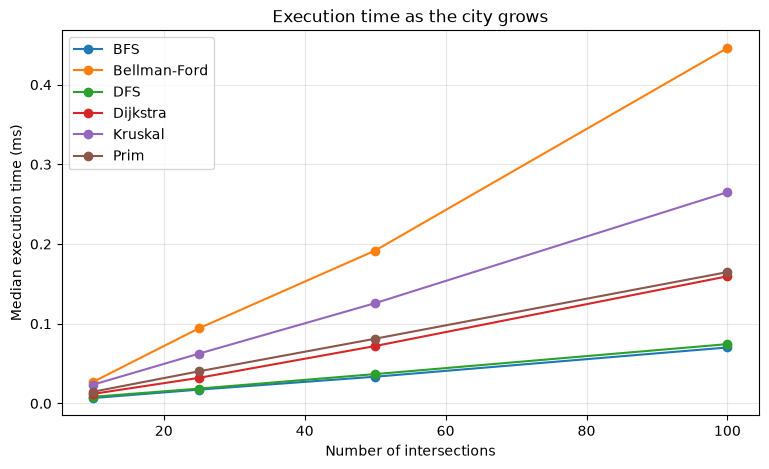

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))
timing_chart(results, ax)
save(fig, "06_execution_time")

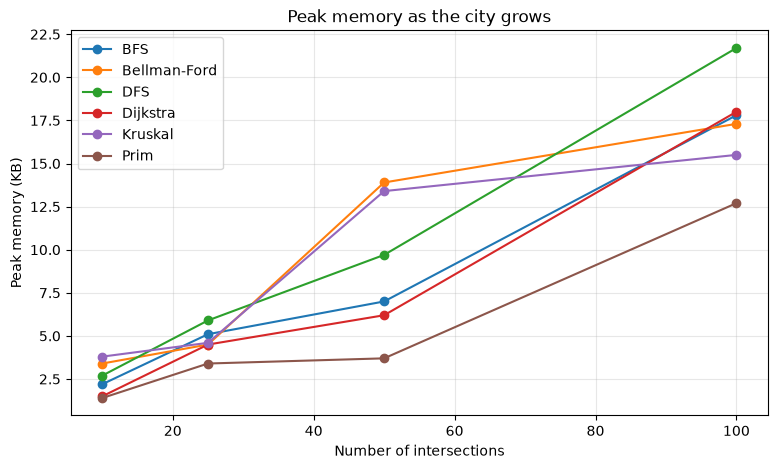

In [30]:
fig, ax = plt.subplots(figsize=(9, 5))
for algorithm, group in results.groupby("Algorithm"):
    group = group.sort_values("Intersections")
    ax.plot(group["Intersections"], group["Peak memory (KB)"], marker="o", label=algorithm)
ax.set_xlabel("Number of intersections")
ax.set_ylabel("Peak memory (KB)")
ax.set_title("Peak memory as the city grows")
ax.grid(True, alpha=0.3)
ax.legend()
save(fig, "06_peak_memory")

## 7. Discussion: which algorithm suits traffic management?

**BFS vs DFS.** Both visit every reachable intersection exactly once, so both run in O(V + E) time.
The measured times are almost identical at every size; when the "Faster" column flips between the two
it is timing noise, not a real difference. BFS is the better tool for traffic monitoring because it also
reports how many roads away each intersection is, which shows how far a disruption spreads. DFS suits
exploring the network region by region, but its recursion depth grows with the longest route.

**Dijkstra vs Bellman-Ford.** Both found the same route and the same cost on every city, as they must.
Dijkstra (O((V + E) log V)) was the faster one at every size, roughly two to three times faster than
Bellman-Ford (see the ratio column). Bellman-Ford (O(V × E)) relaxes every road in every pass. Thanks to
the early stop it ran only a handful of passes (the Passes column) instead of the worst case V - 1,
which is why the gap did not grow even wider. For live navigation Dijkstra is the right choice.
Bellman-Ford still earns its place in the traffic analysis module: it is simple to rerun after road
costs are edited and its pass-by-pass table is easy to explain. It would also tolerate negative costs,
which never occur in this project because every road cost is positive.

**Prim vs Kruskal.** Both reached the same minimum total cost on every city, as they must. Prim
(O(E log V) with a heap) was the faster of the two at every size in our runs and used less memory:
it only pushes the roads that leave the growing tree onto the heap. Kruskal (O(E log E)) first sorts
every road and then runs a union-find check on each one, which costs a little more. Kruskal's strength
is clarity: its sorted list of roads with an accept or reject decision for each is the easier one to
explain to city planners, and it works directly on a plain list of roads.

## 8. Conclusion

* A city road network fits naturally into a weighted graph, and the adjacency list keeps every
  operation simple.
* Dijkstra gives commuters the least-cost route and shows its working through the distance updates.
* Bellman-Ford recomputes routes after congestion or closures and quantifies the extra travel cost.
* BFS and DFS reveal which intersections are reachable and how the city splits into regions when
  roads close.
* Prim and Kruskal find the cheapest set of roads that keeps the whole city connected.
* The experiments agree with the theory: Dijkstra was consistently faster than Bellman-Ford and Prim
  consistently faster than Kruskal, while BFS and DFS were indistinguishable. Every algorithm finished
  in under a millisecond on a city of 100 intersections.

Future improvements: one-way roads (directed edges), live traffic feeds updating the costs,
A* search with a geographic heuristic, and traffic signal timing at the intersections.